https://pypi.org/project/opencv-python/
https://www.geeksforgeeks.org/python/python-program-extract-frames-using-opencv/
https://www.geeksforgeeks.org/python/image-resizing-using-opencv-python/
https://docs.opencv.org/5.0/
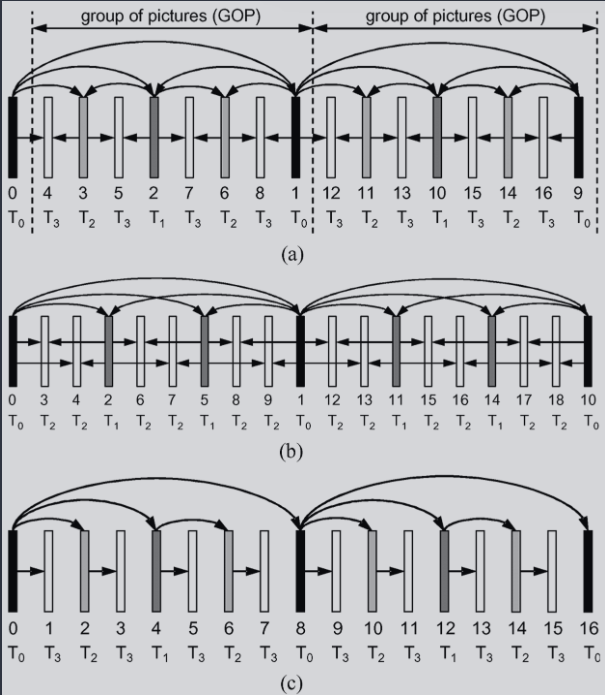

In [1]:
# Use pip to install needed dependencies
# %pip install opencv-python
# %pip install numpy

# Setup

In [2]:
# SVC example demo
import cv2 # OpenCV library
from tkinter import filedialog
import numpy as np

# To begin, choose a video file for demonstration (.mp4)
videoPath = filedialog.askopenfilename(title="select a video",filetypes=[("video files", "*.mp4")])

# Check video was selected
if not videoPath:
    print("please select a video")
else:
    print("selected: ", videoPath)

    video = cv2.VideoCapture(videoPath)

    # Check we can open video file
    if not video.isOpened():
        print("error opening video")
    else:
        print("video opened successfully")

selected:  C:/Users/spenc/Jupyter Notebook/20302274-hd_1080_1920_30fps.mp4
video opened successfully


In [3]:
# Take the video information
fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Resolution:", width, "x", height)
print("Frames:", frame_count)
print("Duration:", frame_count / fps, "seconds")

FPS: 29.97002997002997
Resolution: 1080 x 1920
Frames: 260
Duration: 8.675333333333333 seconds


In [4]:
# # Watch video to see how it looks before our compression

# # Make video window 800*600 so it fits
# windowName = "800*600 window"
# cv2.namedWindow(windowName, cv2.WINDOW_NORMAL)
# cv2.resizeWindow(windowName, 800, 600)

# while video.isOpened():
#     ret, frame = video.read()

#     # reset video to beginning when over
#     if not ret:
#         break

#     cv2.imshow(windowName, frame)
    
#     if cv2.waitKey(25) & 0xFF == ord('q'):
#         break
        
# video.release()
# cv2.destroyAllWindows()

# # reset video after watching
# video = cv2.VideoCapture(videoPath)

# Encoding

In [7]:
# Frame extraction and GOP organization
# Basically go through the video and separate each frame

# GOP size (group of pictures)
gopSize = 9
gops = []
currGop = []

while True:
    ret, frame = video.read()
    if not ret:
        break

    # use gop size to determine which GOP frame is in
    currGop.append(frame)

    if len(currGop) == gopSize:
        gops.append(currGop)

        # last frame is first frame of next GOP
        currGop = [currGop[-1]]

# leftover frames
if len(currGop) > 1:
    gops.append(currGop)

video.release()
# reset video after
video = cv2.VideoCapture(videoPath)

# GOP stats
print("# of GOPs: ", len(gops))
print("Frames in GOP 0:", len(gops[0]))

# first frame of the video, pixel in top left
# GOP 0, frame 0, row 0, pixel 0
print(gops[0][0][0][0])

# of GOPs:  33
Frames in GOP 0: 9
[230 186 166]


In [8]:
# Assign frame types, temporal layer, and references
# Picture for reference at top of notebook

# Basically:
#    position 0 in a GOP is I frame
#    position 8 in a GOP is P frame
#    everything else is a B frame

for gopNdx, gop in enumerate(gops):
    for frameNdx, frame in enumerate(gop):

        if frameNdx == 0:
            frameType = "I"
            
        # cant check if ndx is 8 due to leftover frames
        elif frameNdx == len(gop)-1:
            frameType = "P"

        else:
            frameType = "B"
            
        # Used to specify which frame later
        totalFrameNdx = gopNdx * (gopSize-1) + frameNdx

        # Assign temporal layer and references based on frame ndx
        if frameNdx == 0:
            temporalLayer = 0
            references = []
            
        elif frameNdx == 1:
            temporalLayer = 3
            references = [0,2]

        elif frameNdx == 2:
            temporalLayer = 2
            references = [0,4]

        elif frameNdx == 3:
            temporalLayer = 3
            references = [2,4]
            
        elif frameNdx == 4:
            temporalLayer = 1
            references = [0,8]
        
        elif frameNdx == 5:
            temporalLayer = 3
            references = [4,6]

        elif frameNdx == 6:
            temporalLayer = 2
            references = [4,8]

        
        elif frameNdx == 7:
            temporalLayer = 3
            references = [6,8]

        elif frameNdx == 8:
            temporalLayer = 0
            references = [0]
        
        # Adjust the gop to have the image, frameNdx, frameType, and temporalLayer
        gops[gopNdx][frameNdx] = {
            "image": frame,
            "frameNdx": totalFrameNdx,
            "frameType": frameType,
            "temporalLayer": temporalLayer,
            "references": references
        }

for i in range(9):
    print(gops[0][i]["frameNdx"], "-", gops[0][i]["frameType"], "- T" + str(gops[0][i]["temporalLayer"]), "- Refs:", gops[0][i]["references"])

0 - I - T0 - Refs: []
1 - B - T3 - Refs: [0, 2]
2 - B - T2 - Refs: [0, 4]
3 - B - T3 - Refs: [2, 4]
4 - B - T1 - Refs: [0, 8]
5 - B - T3 - Refs: [4, 6]
6 - B - T2 - Refs: [4, 8]
7 - B - T3 - Refs: [6, 8]
8 - P - T0 - Refs: [0]


Encoder Simplifications:
- does not include motion estimation
- no DCT or transform, so no real compression
- incomplete GOPs are skipped

takes ~80 seconds

In [9]:
# Quantization value (can change to see how it affects video)
q = 10

# taken from figure at top of notebook (a)
codingOrder = [0,8,4,2,1,3,6,5,7]

# Use references to predict frames
for gopNdx, gop in enumerate(gops):

    # if gop is incomplete skip
    if len(gop) < gopSize:
        continue

    # first frame of each GOP is same as last of prev GOP
    if gopNdx > 0:
        gop[0]["encodeReconstructed"] = gops[gopNdx - 1][8]["encodeReconstructed"]

    # have to go in coding order
    for frameNdx in codingOrder:

        frame = gop[frameNdx]

        # shared frame
        if gopNdx > 0 and frameNdx == 0:
            continue
        
        # actual image
        actual = frame["image"].astype(np.int16)

        # I frames (no references)
        if frame["frameType"] == "I":
            frame["quantizedResidual"] = None
            frame["encodedImage"] = frame["image"].copy()
            frame["encodeReconstructed"] = frame["image"].copy()
            

        # other frames
        else:
            references = frame["references"]

            # P frame - 1 reference
            if len(references) == 1:
                refImg = gop[references[0]]["encodeReconstructed"].astype(np.int16)

                prediction = refImg

            # B frame - 2 references
            else:
                refImg1 = gop[references[0]]["encodeReconstructed"].astype(np.float32)
                refImg2 = gop[references[1]]["encodeReconstructed"].astype(np.float32)

                prediction = cv2.addWeighted(
                    refImg1, # ref img
                    0.5,     # weight of ref img
                    refImg2,
                    0.5,
                    0        # gamma (dont need to change)
                ).astype(np.int16)

            # calculate residual
            residual = actual - prediction

            # quantize residual
            qResidual = np.rint(residual.astype(np.float32) / q).astype(np.int16)

            frame["quantizedResidual"] = qResidual

            # reconstruct frame in encoder so
            # predictions use the same ref img the decoder will have
            decodeResidual = qResidual * q
            reconstructed = prediction + decodeResidual

            frame["encodeReconstructed"] = np.clip(reconstructed, 0, 255).astype(np.uint8)

print("finished encoding")    

finished encoding


# Decoding

In [10]:
# Decode from references
for gopNdx, gop in enumerate(gops):

    # skip over if gop is not complete
    if len(gop) < gopSize:
        continue
        
    # move reconstructed shared frame into this GOP
    if gopNdx > 0:
        gop[0]["reconstructed"] = gops[gopNdx - 1][-1]["reconstructed"]
    
    for frameNdx in codingOrder:

        frame = gop[frameNdx]
        
        # shared frames are decoded on prev gop
        if gopNdx > 0 and frameNdx == 0:
            continue

        # I frame is not predicted
        if frame["frameType"] == "I":
            frame["reconstructed"] = frame["encodedImage"].copy()

        else:
            references = frame["references"]

            # P frame - 1 reference
            if len(references) == 1:
                refImg = gop[references[0]]["reconstructed"].astype(np.int16)

                prediction = refImg

            # B frame - 2 references
            else:
                refImg1 = gop[references[0]]["reconstructed"].astype(np.float32)
                refImg2 = gop[references[1]]["reconstructed"].astype(np.float32)

                prediction = cv2.addWeighted(
                    refImg1, # ref img
                    0.5,     # weight of ref img
                    refImg2,
                    0.5,
                    0        # gamma (dont need to change)
                ).astype(np.int16)

            # quantized residual
            qResidual = frame["quantizedResidual"]

            # dequantize
            dequantResidual = qResidual * q

            # reconstruct
            reconFrame = prediction + dequantResidual

            # clip values to be 0-255
            reconstructed = np.clip(reconFrame, 0, 255).astype(np.uint8)

            frame["reconstructed"] = reconstructed

print("finished decoding")

finished decoding


In [11]:
# Create video from reconstructed frames

outputPath = "reconstructedVideo.mp4"

# get frame dimensions
height, width = gops[0][0]["image"].shape[:2]

# video codec
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

# create video writer
out = cv2.VideoWriter(
    outputPath,
    fourcc,
    fps,
    (width, height)
)

# write reconstructed frames
for gopNdx, gop in enumerate(gops):

    # skip incomplete GOP since it wasn't reconstructed
    if len(gop) < gopSize:
        continue

    for frameNdx, frame in enumerate(gop):

        # shared frame
        if gopNdx > 0 and frameNdx == 0:
            continue

        out.write(frame["reconstructed"])

# finish video
out.release()

print("Saved:", outputPath)

Saved: reconstructedVideo.mp4


# Temporal Scalability

Creates a video only containing frames at or below the max temporal layer

In [12]:
# Temporal scalabililty
# Makes a video based on max temporal layer, all higher are not shown

for maxTemporalLayer in range(4):
    
    outputFps = fps / (2 ** (3 - maxTemporalLayer))
    
    outputPath = f"temporalVideo_T{maxTemporalLayer}.mp4"
    
    height, width = gops[0][0]["image"].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    
    out = cv2.VideoWriter(
        outputPath,
        fourcc,
        outputFps,
        (width, height)
    )
    
    for gopNdx, gop in enumerate(gops):
    
        if len(gop) < gopSize:
            continue
    
        for frameNdx, frame in enumerate(gop):
    
            # don't output shared frame twice
            if gopNdx > 0 and frameNdx == 0:
                continue
    
            if frame["temporalLayer"] <= maxTemporalLayer:
                out.write(frame["reconstructed"])
    
    out.release()
    
    print("Created:", outputPath, 
          "- Max layer: T" + str(maxTemporalLayer), 
          "- FPS:", outputFps)

Created: temporalVideo_T0.mp4 - Max layer: T0 - FPS: 3.746253746253746
Created: temporalVideo_T1.mp4 - Max layer: T1 - FPS: 7.492507492507492
Created: temporalVideo_T2.mp4 - Max layer: T2 - FPS: 14.985014985014985
Created: temporalVideo_T3.mp4 - Max layer: T3 - FPS: 29.97002997002997


# Spatial Scalability

In [13]:
# Spatial scalability
# create a low res base layer
for gopNdx, gop in enumerate(gops):

    if len(gop) < gopSize:
        continue

    for frameNdx, frame in enumerate(gop):

        # shared frame
        if gopNdx > 0 and frameNdx == 0:
            continue

        fullImg = frame["reconstructed"]

        # get dimensions of img
        height, width = fullImg.shape[:2]

        baseLayer = cv2.resize(fullImg, (width//4, height//4), interpolation = cv2.INTER_AREA)

        frame["spatialBase"] = baseLayer

print("finished creating base layer")

finished creating base layer


In [14]:
# old and new dimensions
print("Full:", gops[0][0]["reconstructed"].shape)
print("Base:", gops[0][0]["spatialBase"].shape)

Full: (1920, 1080, 3)
Base: (480, 270, 3)


In [15]:
# Create video from spatial base layer
outputPath = "spatialBase.mp4"

# Get dimensions from spatial base
height, width = gops[0][0]["spatialBase"].shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    outputPath,
    fourcc,
    fps,
    (width, height)
)

for gopNdx, gop in enumerate(gops):

    if len(gop) < gopSize:
        continue

    for frameNdx, frame in enumerate(gop):

        # Dont output shared frame twice
        if gopNdx > 0 and frameNdx == 0:
            continue

        out.write(frame["spatialBase"])

out.release()

print("Video created:", outputPath)
print("Resolution:", width, "x", height)
print("FPS:", fps)

Video created: spatialBase.mp4
Resolution: 270 x 480
FPS: 29.97002997002997


Enhancement layer stores what the upscaled base layer is missing, the residual between the full resolution frame and the upscaled prediction.

In [16]:
# create spatial enhancement info
qSpatial = 4

for gopNdx, gop in enumerate(gops):

    if len(gop) < gopSize:
        continue

    for frameNdx, frame in enumerate(gop):

        # shared frame
        if gopNdx > 0 and frameNdx == 0:
            continue

        fullImg = frame["reconstructed"]

        height, width = fullImg.shape[:2]

        # upscale base layer using cv2
        spatialPrediction = cv2.resize(
            frame["spatialBase"],
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        # enhancement inmformation
        # this is what is missing from the upscaled base layer
        spatialResidual = (
            fullImg.astype(np.int16)
            - spatialPrediction.astype(np.int16)
        )

        frame["spatialPrediction"] = spatialPrediction
        frame["spatialResidual"] = np.rint(spatialResidual.astype(np.float32)/qSpatial).astype(np.int16)

print("finished")

finished


In [17]:
# reconstruct full res
# reconstruct full resolution using spatial enhancement and base layer
for gopNdx, gop in enumerate(gops):

    if len(gop) < gopSize:
        continue

    for frameNdx, frame in enumerate(gop):

        # shared frame
        if gopNdx > 0 and frameNdx == 0:
            continue

        prediction = frame["spatialPrediction"].astype(np.int16)
        residual = frame["spatialResidual"] * qSpatial

        # add enhancement information back
        spatialEnhanced = prediction + residual

        # convert back to image
        spatialEnhanced = np.clip(
            spatialEnhanced,
            0,
            255
        ).astype(np.uint8)

        frame["spatialEnhanced"] = spatialEnhanced

print("finished reconstruction")

finished reconstruction


In [18]:
# see what the max pixel error between the reconstructed and decoded video
maxErr = 0
for gopNdx, gop in enumerate(gops):
    if len(gop) < gopSize:
        continue
    for frameNdx, frame in enumerate(gop):
        if gopNdx > 0 and frameNdx == 0:
            continue
        err = np.abs(
            frame["spatialEnhanced"].astype(np.int16)
            - frame["reconstructed"].astype(np.int16)
        ).max()
        maxErr = max(maxErr, err)

# check the max pixel error between the enhanced frames and the decoded full-res frames
# limit comes from rounding to nearest multiple of qSpatial
print("Max pixel error:", maxErr, "(limit", qSpatial // 2, ")")

Max pixel error: 2 (limit 2 )


# Quality Scalability

How close each pixel's value is to the original at the same resolution and frame rate

Simplification:
- only works on the first GOP
- takes too long otherwise

In [21]:
# Quality scalability
# create low quality base and enhancement information

qBase = 40

gop = gops[0]

for frameNdx, frame in enumerate(gop):

    # I frame does not use prediction
    if frame["frameType"] == "I":
        frame["qualityBase"] = frame["image"].copy()
        frame["qualityEnhancement"] = None
        continue

    actual = frame["image"].astype(np.int16)

    references = frame["references"]
    
     # P frame - 1 reference
    if len(references) == 1:
        refImg = gop[references[0]]["encodeReconstructed"].astype(np.int16)

        prediction = refImg

    # B frame - 2 references
    else:
        refImg1 = gop[references[0]]["encodeReconstructed"].astype(np.float32)
        refImg2 = gop[references[1]]["encodeReconstructed"].astype(np.float32)

        prediction = cv2.addWeighted(
            refImg1,
            0.5,
            refImg2,
            0.5,
            0
        ).astype(np.int16)

    # calculate original residual
    residual = actual - prediction

    # quantization for base quality
    qBaseResidual = np.rint(residual.astype(np.float32) / qBase).astype(np.int16)

    # residual represented by base layer
    baseResidual = qBaseResidual * qBase

    # reconstruct low quality base
    qualityBase = prediction + baseResidual

    qualityBase = np.clip(qualityBase,0,255).astype(np.uint8)

    # information missing from base quality
    qualityEnhancement = residual - baseResidual

    frame["qualityBase"] = qualityBase
    frame["baseResidual"] = baseResidual
    frame["qualityEnhancement"] = qualityEnhancement

print("finished")

finished


In [22]:
# reconstruct enhanced quality

gop = gops[0]

for frameNdx, frame in enumerate(gop):

    # I frame has no references
    if frame["frameType"] == "I":
        frame["qualityEnhanced"] = frame["image"].copy()
        continue

    references = frame["references"]

    # P frame - 1 reference
    if len(references) == 1:
        refImg = gop[references[0]]["encodeReconstructed"].astype(np.int16)

        prediction = refImg

    # B frame - 2 references
    else:
        refImg1 = gop[references[0]]["encodeReconstructed"].astype(np.float32)
        refImg2 = gop[references[1]]["encodeReconstructed"].astype(np.float32)

        prediction = cv2.addWeighted(
            refImg1,
            0.5,
            refImg2,
            0.5,
            0
        ).astype(np.int16)

    baseResidual = frame["baseResidual"]

    # add enhancement information
    enhancedResidual = (baseResidual+ frame["qualityEnhancement"])

    qualityEnhanced = prediction + enhancedResidual

    frame["qualityEnhanced"] = np.clip(qualityEnhanced,0,255).astype(np.uint8)

print("finished quality reconstruction")

finished quality reconstruction


Base differs from the orginal, enhanced matches

This is a simplified example, although it is quantized, it is not transformed or entropy encoded, so the enhanced frame will match every time.

In [23]:
# Check quality scalability

for frameNdx, frame in enumerate(gops[0]):

    baseMatch = np.array_equal(
        frame["qualityBase"],
        frame["image"]
    )

    enhancedMatch = np.array_equal(
        frame["qualityEnhanced"],
        frame["image"]
    )

    print(
        "Frame:", frameNdx,
        "- Base matches:", baseMatch,
        "- Enhanced matches:", enhancedMatch
    )

Frame: 0 - Base matches: True - Enhanced matches: True
Frame: 1 - Base matches: False - Enhanced matches: True
Frame: 2 - Base matches: False - Enhanced matches: True
Frame: 3 - Base matches: False - Enhanced matches: True
Frame: 4 - Base matches: False - Enhanced matches: True
Frame: 5 - Base matches: False - Enhanced matches: True
Frame: 6 - Base matches: False - Enhanced matches: True
Frame: 7 - Base matches: False - Enhanced matches: True
Frame: 8 - Base matches: False - Enhanced matches: True
